In [2]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd

# Load the events file
def load_log_file(path):
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    # Get available tags (metric names)
    return ea



In [3]:
import os
from pathlib import Path
import pandas as pd

def load_all_logs(log_dir):
    """Load all TensorBoard event files from a directory into a single DataFrame"""
    
    # Find all event files in the directory
    log_files = []
    for file in os.listdir(log_dir):
        if file.startswith('events.out.tfevents'):
            log_files.append(os.path.join(log_dir, file))
    
    if not log_files:
        print(f"No TensorBoard log files found in {log_dir}")
        return pd.DataFrame()
    
    # Load all files and combine
    all_data = []
    
    for log_file in log_files:
        print(f"Loading {log_file}...")
        ea = load_log_file(log_file)
        
        # Get all scalar tags
        scalar_tags = ea.Tags()['scalars']
        
        # Extract all scalars from this file
        for tag in scalar_tags:
            events = ea.Scalars(tag)
            temp_df = pd.DataFrame(events)
            temp_df['metric'] = tag
            all_data.append(temp_df)
    
    # Combine all data
    full_df = pd.concat(all_data, ignore_index=True)
    
    # Sort by step
    full_df = full_df.sort_values('step').reset_index(drop=True)
    
    return full_df



In [4]:
def plot_metric(df, metric):
    # Filter rows
    filtered = df[df['metric'] == metric]

    # Select columns
    metric_df = filtered[['step', 'value']]

    metric_df.plot(x='step', y='value')
    return metric_df

In [21]:
# Usage:
log_directory = 'models/dorkS_CNN_test.log/dorkS_0'  # or wherever your logs are
full_df = load_all_logs(log_directory)
print(full_df.head())

Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764582010.Williams-MacBook-Air.local.87707.21...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764778954.Williams-MacBook-Air.local.12914.1...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764781024.Williams-MacBook-Air.local.12914.3...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764787174.Williams-MacBook-Air.local.12914.13...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764793339.Williams-MacBook-Air.local.12914.21...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764575764.Williams-MacBook-Air.local.87707.19...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764738458.Williams-MacBook-Air.local.50058.17...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764789279.Williams-MacBook-Air.local.12914.15...
Loading models/dorkS_CNN_test.log/dorkS_0/events.out.tfevents.1764648466.Williams-MacBook-Air.local.91930.

In [17]:
print(full_df['metric'].unique())

['rollout/ep_len_mean' 'rollout/ep_rew_mean' 'time/fps'
 'train/explained_variance' 'train/clip_range' 'train/learning_rate'
 'train/clip_fraction' 'train/loss' 'train/policy_gradient_loss'
 'train/approx_kl' 'train/value_loss' 'train/entropy_loss' 'black_wins']


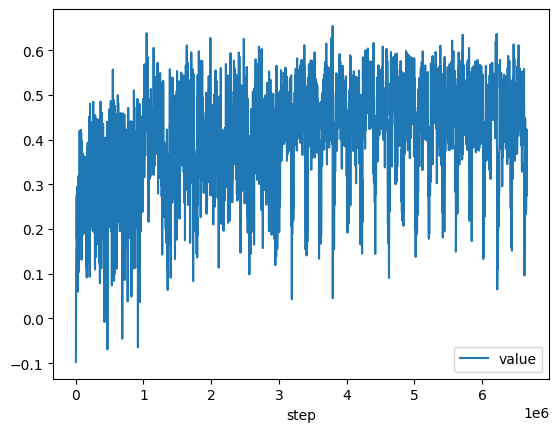

In [22]:
bw = plot_metric(full_df, 'train/explained_variance')

In [23]:
max(bw['value'])

0.6545006036758423

In [24]:
min(bw['value'])

-0.0971825122833252

In [25]:
bw['value'].std()

0.11088622154143246

In [26]:
bw['value'][1500:].std()

0.09703997359588365